# # Breast Cancer Classification - Complete Machine Learning Project
# 
# This project covers all stages of machine learning lifecycle for breast cancer classification.

# ## 1. Import Required Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           confusion_matrix, classification_report, roc_curve, auc, 
                           precision_recall_curve, roc_auc_score)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
import warnings
warnings.filterwarnings('ignore')

# %%
# Set style for better visualizations
plt.style.use('seaborn')
# or more specifically
plt.style.use('seaborn-darkgrid')
plt.style.use('seaborn-whitegrid')
plt.style.use('seaborn-dark')
plt.style.use('seaborn-notebook')
sns.set_palette("husl")

# ## 2. Dataset Loading

In [17]:
# Load the dataset
df = pd.read_csv("dataset.csv")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()

# %%
# Display dataset information
print("Dataset Information:")
print("=" * 50)
df.info()

# %%
# Display basic statistics
print("\nDataset Statistics:")
print("=" * 50)
df.describe()


First 5 rows of the dataset:
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


# ## 3. Data Preprocessing

In [18]:
def preprocess_data(df):
    """
    Perform comprehensive data preprocessing
    """
    df_clean = df.copy()
    
    print("Initial dataset shape:", df_clean.shape)
    
    # 3.1 Handling irrelevant columns
    # Drop 'id' column as it's not useful for prediction
    if 'id' in df_clean.columns:
        df_clean = df_clean.drop('id', axis=1)
        print("Dropped 'id' column")
    
    # 3.2 Handling missing values
    print("\nMissing values before handling:")
    print(df_clean.isnull().sum())
    
    # Check for missing values and handle them
    missing_cols = df_clean.columns[df_clean.isnull().any()].tolist()
    if missing_cols:
        # For numerical columns, fill with median
        numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
        numerical_missing = [col for col in missing_cols if col in numerical_cols]
        
        for col in numerical_missing:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            print(f"Filled missing values in {col} with median")
    
    print("\nMissing values after handling:")
    print(df_clean.isnull().sum())
    
    # 3.3 Handling duplicate values
    duplicates = df_clean.duplicated().sum()
    print(f"\nNumber of duplicate rows: {duplicates}")
    if duplicates > 0:
        df_clean = df_clean.drop_duplicates()
        print(f"Removed {duplicates} duplicate rows")
    
    # 3.4 Handling categorical values
    print("\nCategorical variables:")
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    print(categorical_cols)
    
    # Encode the target variable 'diagnosis'
    if 'diagnosis' in df_clean.columns:
        le = LabelEncoder()
        df_clean['diagnosis_encoded'] = le.fit_transform(df_clean['diagnosis'])
        # M (Malignant) = 1, B (Benign) = 0
        print(f"Encoded 'diagnosis' column: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    
    print(f"\nFinal dataset shape after preprocessing: {df_clean.shape}")
    return df_clean

# Preprocess the data
df_processed = preprocess_data(df)
df_processed.head()

Initial dataset shape: (569, 33)
Dropped 'id' column

Missing values before handling:
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst 

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,diagnosis_encoded
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1


# ## 4. Feature Engineering

In [19]:
def feature_engineering(df):
    """
    Perform feature engineering including outlier detection, feature selection, and scaling
    """
    df_fe = df.copy()
    
    # Separate features and target
    X = df_fe.drop(['diagnosis', 'diagnosis_encoded'], axis=1)
    y = df_fe['diagnosis_encoded']
    
    print("Feature Engineering Steps:")
    print("=" * 50)
    
    # 4.1 Outlier Detection using IQR method
    print("\n1. Outlier Detection:")
    numerical_cols = X.select_dtypes(include=[np.number]).columns
    
    outlier_info = {}
    for col in numerical_cols:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
        outlier_percentage = (len(outliers) / len(X)) * 100
        outlier_info[col] = outlier_percentage
        
        if outlier_percentage > 5:  # If more than 5% outliers, cap them
            X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
            X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])
            print(f"  - Capped outliers in {col} ({outlier_percentage:.2f}%)")
    
    # 4.2 Feature Selection
    print("\n2. Feature Selection:")

    # Ensure only numeric columns are passed
    X = X.select_dtypes(include=[np.number])

    # Handle missing or infinite values before SelectKBest
    X = X.replace([np.inf, -np.inf], np.nan)

    # Drop columns that are entirely NaN
    all_nan_cols = X.columns[X.isna().all()]
    if len(all_nan_cols) > 0:
        print(f"🧹 Dropping entirely NaN columns: {list(all_nan_cols)}")
        X = X.drop(columns=all_nan_cols)

    # Print summary of missing/infinite values
    missing_summary = X.isnull().sum()
    if missing_summary.sum() > 0:
        print("⚠️ Missing values detected after outlier handling:")
        print(missing_summary[missing_summary > 0])
        print("→ Filling with column medians.")
        X = X.fillna(X.median())

    # Double-check no missing or inf remains
    assert not np.isinf(X.to_numpy()).any(), "❌ Infinite values remain in X!"
    assert not np.isnan(X.to_numpy()).any(), "❌ NaN values remain in X!"


    # Method 1: Using SelectKBest
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)

    feature_scores = pd.DataFrame({
        'Feature': X.columns,
        'Score': selector.scores_,
        'P-value': selector.pvalues_
    }).sort_values('Score', ascending=False)
    
    print("Feature scores (ANOVA F-value):")
    print(feature_scores)
    
    # Select top features (you can adjust the number)
    top_features = feature_scores.head(8)['Feature'].tolist()
    print(f"\nSelected top {len(top_features)} features: {top_features}")
    
    X_selected = X[top_features]
    
    # 4.3 Feature Importance using Random Forest
    print("\n3. Feature Importance (Random Forest):")
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(feature_importance.head(10))
    
    # 4.4 Handle Class Imbalance
    print(f"\n4. Class Distribution:")
    class_distribution = y.value_counts()
    print(class_distribution)
    
    if abs(class_distribution[0] - class_distribution[1]) / len(y) > 0.1:
        print("Warning: Significant class imbalance detected!")
        # In practice, you might use SMOTE or other techniques here
    
    # 4.5 Feature Scaling
    print("\n5. Feature Scaling:")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)
    X_scaled = pd.DataFrame(X_scaled, columns=X_selected.columns)
    
    print("Features scaled using StandardScaler")
    
    return X_scaled, y, top_features, scaler, feature_scores, feature_importance

# Perform feature engineering
X, y, selected_features, scaler, feature_scores, feature_importance = feature_engineering(df_processed)

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

Feature Engineering Steps:

1. Outlier Detection:
  - Capped outliers in radius_se (6.68%)
  - Capped outliers in perimeter_se (6.68%)
  - Capped outliers in area_se (11.42%)
  - Capped outliers in smoothness_se (5.27%)
  - Capped outliers in area_worst (6.15%)

2. Feature Selection:
🧹 Dropping entirely NaN columns: ['Unnamed: 32']
Feature scores (ANOVA F-value):
                    Feature       Score        P-value
23               area_worst  971.473689  5.310111e-125
27     concave points_worst  964.385393  1.969100e-124
22          perimeter_worst  897.944219  5.771397e-119
7       concave points_mean  861.676020  7.101150e-116
20             radius_worst  860.781707  8.482292e-116
2            perimeter_mean  697.235272  8.436251e-101
13                  area_se  682.507418   2.349510e-99
0               radius_mean  646.981021   8.465941e-96
3                 area_mean  573.060747   4.734564e-88
6            concavity_mean  533.793126   9.966556e-84
26          concavity_worst  

# ## 5. Data Visualization

Creating Visualizations...


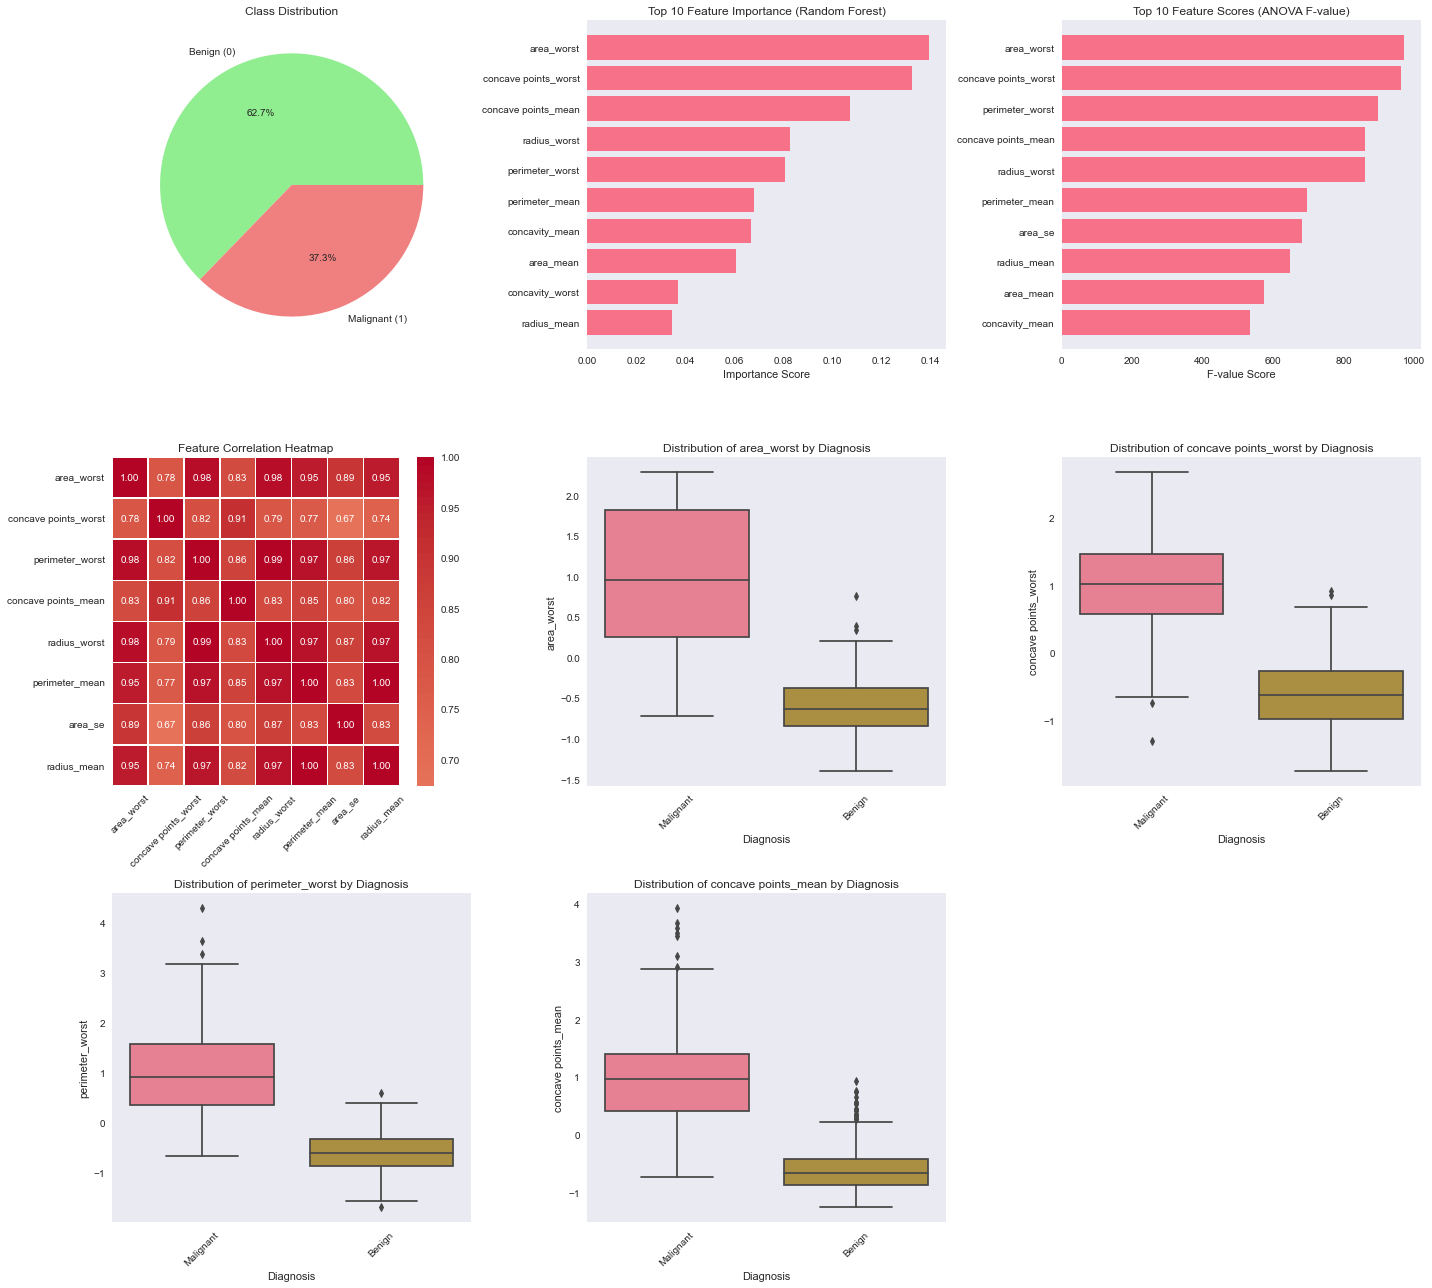


Creating pairplot...


<Figure size 1080x864 with 0 Axes>

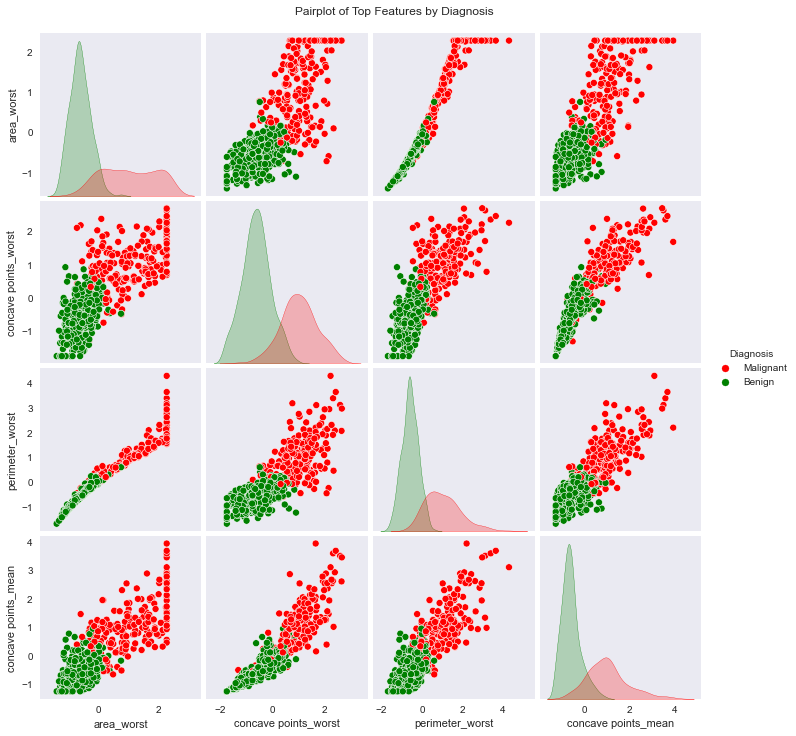

All visualizations saved successfully!


In [20]:

def create_visualizations(df, X, y, feature_scores, feature_importance):
    """
    Create comprehensive visualizations for the dataset
    """
    print("Creating Visualizations...")
    
    # Set up the plotting style
    plt.rcParams['figure.figsize'] = (15, 12)
    
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(20, 18))
    
    # 5.1 Class Distribution
    plt.subplot(3, 3, 1)
    class_counts = y.value_counts()
    plt.pie(class_counts.values, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', 
            colors=['lightgreen', 'lightcoral'])
    plt.title('Class Distribution')
    
    # 5.2 Feature Importance Plot
    plt.subplot(3, 3, 2)
    top_10_features = feature_importance.head(10)
    plt.barh(top_10_features['Feature'], top_10_features['Importance'])
    plt.title('Top 10 Feature Importance (Random Forest)')
    plt.xlabel('Importance Score')
    plt.gca().invert_yaxis()
    
    # 5.3 Feature Scores (ANOVA)
    plt.subplot(3, 3, 3)
    top_10_scores = feature_scores.head(10)
    plt.barh(top_10_scores['Feature'], top_10_scores['Score'])
    plt.title('Top 10 Feature Scores (ANOVA F-value)')
    plt.xlabel('F-value Score')
    plt.gca().invert_yaxis()
    
    # 5.4 Correlation Heatmap
    plt.subplot(3, 3, 4)
    correlation_matrix = X.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', linewidths=0.5)
    plt.title('Feature Correlation Heatmap')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # 5.5 Box plots for top features by class
    for i, feature in enumerate(selected_features[:4]):
        plt.subplot(3, 3, 5 + i)
        df_plot = pd.DataFrame({feature: X[feature], 'Diagnosis': y.map({0: 'Benign', 1: 'Malignant'})})
        sns.boxplot(x='Diagnosis', y=feature, data=df_plot)
        plt.title(f'Distribution of {feature} by Diagnosis')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('breast_cancer_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5.6 Pairplot for top features
    print("\nCreating pairplot...")
    df_pairplot = X[selected_features[:4]].copy()
    df_pairplot['Diagnosis'] = y.map({0: 'Benign', 1: 'Malignant'})
    
    plt.figure(figsize=(15, 12))
    sns.pairplot(df_pairplot, hue='Diagnosis', palette={'Benign': 'green', 'Malignant': 'red'})
    plt.suptitle('Pairplot of Top Features by Diagnosis', y=1.02)
    plt.savefig('pairplot_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("All visualizations saved successfully!")

# Create visualizations
create_visualizations(df_processed, X, y, feature_scores, feature_importance)

# ## 6. Train-Test Split

In [21]:
def split_data(X, y, test_size=0.2, random_state=42):
    """
    Split data into training and testing sets
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("Data Split Summary:")
    print("=" * 30)
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    print(f"Training set class distribution:\n{y_train.value_counts()}")
    print(f"Testing set class distribution:\n{y_test.value_counts()}")
    
    return X_train, X_test, y_train, y_test

# Split the data
X_train, X_test, y_train, y_test = split_data(X, y)


Data Split Summary:
Training set shape: (455, 8)
Testing set shape: (114, 8)
Training set class distribution:
0    285
1    170
Name: diagnosis_encoded, dtype: int64
Testing set class distribution:
0    72
1    42
Name: diagnosis_encoded, dtype: int64


# ## 7. Model Creation and Comparison

In [22]:
def create_and_compare_models(X_train, X_test, y_train, y_test):
    """
    Create multiple models and compare their performance
    """
    models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'SVM': SVC(probability=True, random_state=42)
    }
    
    results = {}
    
    print("Training and Evaluating Models...")
    print("=" * 50)
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc_score = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
        
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'auc_score': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"{name} Results:")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        if auc_score:
            print(f"  AUC Score: {auc_score:.4f}")
    
    return results

# Train and compare models
model_results = create_and_compare_models(X_train, X_test, y_train, y_test)

Training and Evaluating Models...

Training Logistic Regression...
Logistic Regression Results:
  Accuracy:  0.9649
  Precision: 0.9750
  Recall:    0.9286
  F1-Score:  0.9512
  AUC Score: 0.9980

Training K-Nearest Neighbors...
K-Nearest Neighbors Results:
  Accuracy:  0.9649
  Precision: 0.9750
  Recall:    0.9286
  F1-Score:  0.9512
  AUC Score: 0.9962

Training Decision Tree...
Decision Tree Results:
  Accuracy:  0.9211
  Precision: 0.8837
  Recall:    0.9048
  F1-Score:  0.8941
  AUC Score: 0.9177

Training Random Forest...
Random Forest Results:
  Accuracy:  0.9561
  Precision: 0.9744
  Recall:    0.9048
  F1-Score:  0.9383
  AUC Score: 0.9929

Training Gradient Boosting...
Gradient Boosting Results:
  Accuracy:  0.9561
  Precision: 0.9512
  Recall:    0.9286
  F1-Score:  0.9398
  AUC Score: 0.9924

Training SVM...
SVM Results:
  Accuracy:  0.9386
  Precision: 0.9730
  Recall:    0.8571
  F1-Score:  0.9114
  AUC Score: 0.9974


# ## 8. Performance Evaluation

Comprehensive Model Evaluation

Model Comparison (sorted by Accuracy):
                 Model  Accuracy  Precision    Recall  F1-Score  AUC-Score
0  Logistic Regression  0.964912   0.975000  0.928571  0.951220   0.998016
1  K-Nearest Neighbors  0.964912   0.975000  0.928571  0.951220   0.996197
3        Random Forest  0.956140   0.974359  0.904762  0.938272   0.992890
4    Gradient Boosting  0.956140   0.951220  0.928571  0.939759   0.992394
5                  SVM  0.938596   0.972973  0.857143  0.911392   0.997354
2        Decision Tree  0.921053   0.883721  0.904762  0.894118   0.917659


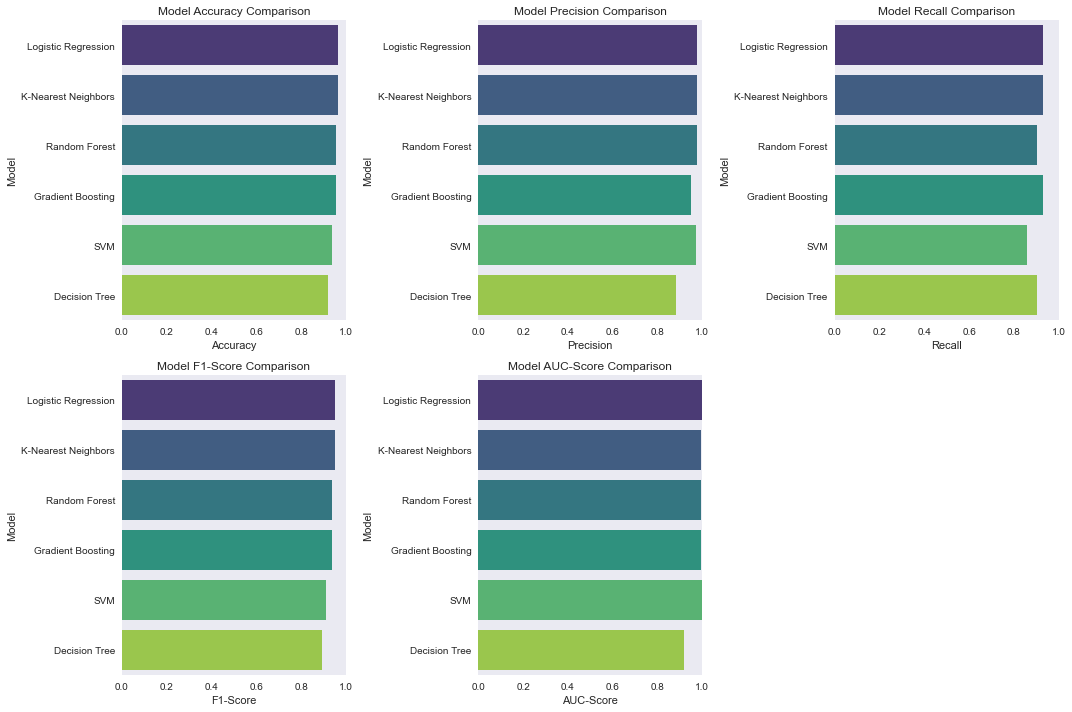

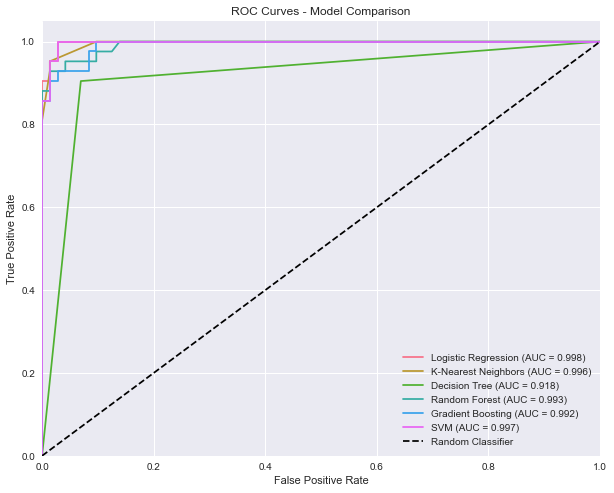

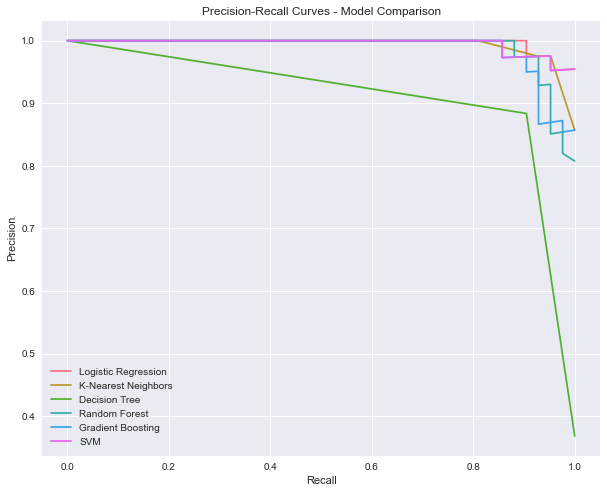


DETAILED CLASSIFICATION REPORTS

Logistic Regression - Classification Report:
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



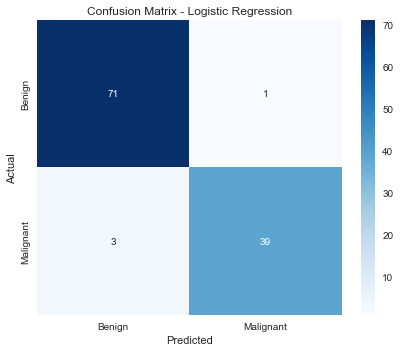


K-Nearest Neighbors - Classification Report:
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



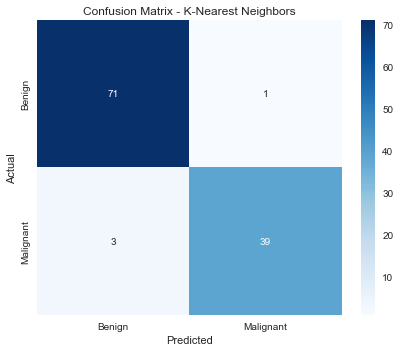


Random Forest - Classification Report:
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



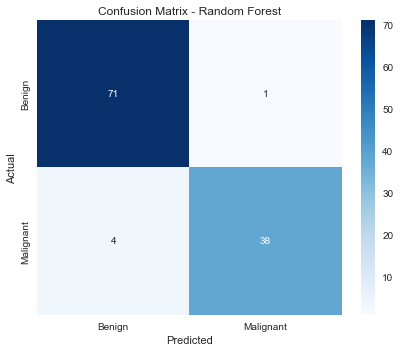

In [23]:
def evaluate_models(model_results, y_test):
    """
    Comprehensive evaluation of all models with visualizations
    """
    print("Comprehensive Model Evaluation")
    print("=" * 50)
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame({
        'Model': list(model_results.keys()),
        'Accuracy': [result['accuracy'] for result in model_results.values()],
        'Precision': [result['precision'] for result in model_results.values()],
        'Recall': [result['recall'] for result in model_results.values()],
        'F1-Score': [result['f1_score'] for result in model_results.values()],
        'AUC-Score': [result['auc_score'] for result in model_results.values()]
    }).sort_values('Accuracy', ascending=False)
    
    print("\nModel Comparison (sorted by Accuracy):")
    print(comparison_df)
    
    # Visualization 1: Model Comparison Bar Chart
    plt.figure(figsize=(15, 10))
    
    # Accuracy comparison
    plt.subplot(2, 3, 1)
    sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')
    plt.title('Model Accuracy Comparison')
    plt.xlim(0, 1)
    
    # Precision comparison
    plt.subplot(2, 3, 2)
    sns.barplot(x='Precision', y='Model', data=comparison_df, palette='viridis')
    plt.title('Model Precision Comparison')
    plt.xlim(0, 1)
    
    # Recall comparison
    plt.subplot(2, 3, 3)
    sns.barplot(x='Recall', y='Model', data=comparison_df, palette='viridis')
    plt.title('Model Recall Comparison')
    plt.xlim(0, 1)
    
    # F1-Score comparison
    plt.subplot(2, 3, 4)
    sns.barplot(x='F1-Score', y='Model', data=comparison_df, palette='viridis')
    plt.title('Model F1-Score Comparison')
    plt.xlim(0, 1)
    
    # AUC-Score comparison
    plt.subplot(2, 3, 5)
    sns.barplot(x='AUC-Score', y='Model', data=comparison_df, palette='viridis')
    plt.title('Model AUC-Score Comparison')
    plt.xlim(0, 1)
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Visualization 2: ROC Curves
    plt.figure(figsize=(10, 8))
    for name, result in model_results.items():
        if result['probabilities'] is not None:
            fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Model Comparison')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Visualization 3: Precision-Recall Curves
    plt.figure(figsize=(10, 8))
    for name, result in model_results.items():
        if result['probabilities'] is not None:
            precision, recall, _ = precision_recall_curve(y_test, result['probabilities'])
            plt.plot(recall, precision, label=f'{name}')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves - Model Comparison')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Detailed classification reports for top 3 models
    print("\n" + "="*50)
    print("DETAILED CLASSIFICATION REPORTS")
    print("="*50)
    
    top_models = comparison_df.head(3)['Model'].tolist()
    
    for model_name in top_models:
        print(f"\n{model_name} - Classification Report:")
        print("-" * 40)
        y_pred = model_results[model_name]['predictions']
        print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
        
        # Confusion Matrix
        plt.figure(figsize=(6, 5))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Benign', 'Malignant'],
                    yticklabels=['Benign', 'Malignant'])
        plt.title(f'Confusion Matrix - {model_name}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
    
    return comparison_df

# Evaluate all models
comparison_results = evaluate_models(model_results, y_test)

# ## 9. Hyperparameter Tuning and Cross Validation

In [24]:
def hyperparameter_tuning_best_model(X_train, y_train, X_test, y_test, comparison_df):
    """
    Perform hyperparameter tuning on the best model using GridSearchCV
    """
    # Select the best model based on accuracy
    best_model_name = comparison_df.iloc[0]['Model']
    best_model_original = model_results[best_model_name]['model']
    
    print(f"Performing Hyperparameter Tuning for: {best_model_name}")
    print("=" * 50)
    
    # Define parameter grids for different models
    param_grids = {
        'Random Forest': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'Gradient Boosting': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 4, 5]
        },
        'SVM': {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto', 0.1, 0.01],
            'kernel': ['rbf', 'linear']
        },
        'Logistic Regression': {
            'C': [0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        },
        'K-Nearest Neighbors': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'Decision Tree': {
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    }
    
    # Get the appropriate parameter grid
    param_grid = param_grids.get(best_model_name, {})
    
    if not param_grid:
        print(f"No parameter grid defined for {best_model_name}")
        return best_model_original, model_results[best_model_name]
    
    # Perform GridSearchCV with cross-validation
    print("Performing GridSearchCV...")
    grid_search = GridSearchCV(
        estimator=best_model_original,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"\nBest parameters for {best_model_name}:")
    print(grid_search.best_params_)
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Get the best model
    best_tuned_model = grid_search.best_estimator_
    
    # Evaluate the tuned model
    y_pred_tuned = best_tuned_model.predict(X_test)
    y_pred_proba_tuned = best_tuned_model.predict_proba(X_test)[:, 1] if hasattr(best_tuned_model, "predict_proba") else None
    
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    precision_tuned = precision_score(y_test, y_pred_tuned)
    recall_tuned = recall_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned) if y_pred_proba_tuned is not None else None
    
    print(f"\nTuned {best_model_name} Performance:")
    print(f"  Accuracy:  {accuracy_tuned:.4f}")
    print(f"  Precision: {precision_tuned:.4f}")
    print(f"  Recall:    {recall_tuned:.4f}")
    print(f"  F1-Score:  {f1_tuned:.4f}")
    if auc_tuned:
        print(f"  AUC Score: {auc_tuned:.4f}")
    
    # Compare with original model
    original_accuracy = model_results[best_model_name]['accuracy']
    improvement = accuracy_tuned - original_accuracy
    
    print(f"\nImprovement after tuning: {improvement:.4f} ({improvement*100:.2f}%)")
    
    # Cross-validation scores for the tuned model
    print("\nCross-validation scores for tuned model:")
    cv_scores = cross_val_score(best_tuned_model, X_train, y_train, 
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                              scoring='accuracy')
    print(f"CV Scores: {cv_scores}")
    print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    return best_tuned_model, {
        'accuracy': accuracy_tuned,
        'precision': precision_tuned,
        'recall': recall_tuned,
        'f1_score': f1_tuned,
        'auc_score': auc_tuned,
        'predictions': y_pred_tuned,
        'probabilities': y_pred_proba_tuned,
        'cv_scores': cv_scores
    }

# Perform hyperparameter tuning
best_tuned_model, tuned_results = hyperparameter_tuning_best_model(
    X_train, y_train, X_test, y_test, comparison_results
)

Performing Hyperparameter Tuning for: Logistic Regression
Performing GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters for Logistic Regression:
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.9538

Tuned Logistic Regression Performance:
  Accuracy:  0.9737
  Precision: 0.9756
  Recall:    0.9524
  F1-Score:  0.9639
  AUC Score: 0.9987

Improvement after tuning: 0.0088 (0.88%)

Cross-validation scores for tuned model:
CV Scores: [0.95604396 0.98901099 0.91208791 0.95604396 0.95604396]
Mean CV Score: 0.9538 (+/- 0.0489)


# ## 10. Model Saving and Loading

In [25]:
import joblib
import json

def save_model_and_artifacts(model, scaler, selected_features, model_name="best_breast_cancer_model"):
    """
    Save the trained model and all necessary artifacts
    """
    # Create a dictionary with all artifacts
    artifacts = {
        'model': model,
        'scaler': scaler,
        'selected_features': selected_features,
        'feature_names': list(selected_features),
        'model_type': type(model).__name__
    }
    
    # Save model
    joblib.dump(artifacts, f'{model_name}.pkl')
    print(f"Model saved as {model_name}.pkl")
    
    # Save feature information
    feature_info = {
        'selected_features': selected_features,
        'feature_count': len(selected_features)
    }
    
    with open(f'{model_name}_features.json', 'w') as f:
        json.dump(feature_info, f, indent=4)
    print(f"Feature information saved as {model_name}_features.json")
    
    return artifacts

def load_model_and_artifacts(model_path):
    """
    Load the saved model and artifacts
    """
    artifacts = joblib.load(model_path)
    print(f"Model loaded from {model_path}")
    print(f"Model type: {artifacts['model_type']}")
    print(f"Number of features: {len(artifacts['selected_features'])}")
    
    return artifacts

# Save the best model
artifacts = save_model_and_artifacts(best_tuned_model, scaler, selected_features)

Model saved as best_breast_cancer_model.pkl
Feature information saved as best_breast_cancer_model_features.json


# ## 11. Model Testing and Prediction

In [26]:
def predict_new_sample(model_artifacts, sample_data):
    """
    Make predictions on new sample data
    """
    model = model_artifacts['model']
    scaler = model_artifacts['scaler']
    selected_features = model_artifacts['selected_features']
    
    # Ensure sample data has the right features
    sample_df = pd.DataFrame([sample_data])
    
    # Select only the required features
    sample_selected = sample_df[selected_features]
    
    # Scale the features
    sample_scaled = scaler.transform(sample_selected)
    
    # Make prediction
    prediction = model.predict(sample_scaled)[0]
    probability = model.predict_proba(sample_scaled)[0] if hasattr(model, "predict_proba") else None
    
    # Convert prediction to meaningful output
    diagnosis = "Malignant" if prediction == 1 else "Benign"
    
    result = {
        'prediction': prediction,
        'diagnosis': diagnosis,
        'probability': probability
    }
    
    if probability is not None:
        result['confidence'] = max(probability) * 100
        result['probability_benign'] = probability[0] * 100
        result['probability_malignant'] = probability[1] * 100
    
    return result

# Test the model with a sample prediction
print("Testing Model with Sample Data...")
print("=" * 40)

# Create a sample based on the dataset statistics
sample_data = {
    'radius_mean': 15.0,
    'texture_mean': 20.0,
    'perimeter_mean': 100.0,
    'area_mean': 700.0,
    'smoothness_mean': 0.1,
    'compactness_mean': 0.15,
    'concavity_mean': 0.1,
    'concave points_mean': 0.05
}

# Ensure we have all required features
for feature in selected_features:
    if feature not in sample_data:
        sample_data[feature] = np.random.normal(0, 1)  # Default value

# Make prediction
prediction_result = predict_new_sample(artifacts, sample_data)

print("Prediction Results:")
print(f"Diagnosis: {prediction_result['diagnosis']}")
print(f"Prediction: {prediction_result['prediction']}")
if 'confidence' in prediction_result:
    print(f"Confidence: {prediction_result['confidence']:.2f}%")
    print(f"Probability Benign: {prediction_result['probability_benign']:.2f}%")
    print(f"Probability Malignant: {prediction_result['probability_malignant']:.2f}%")

Testing Model with Sample Data...
Prediction Results:
Diagnosis: Benign
Prediction: 0
Confidence: 100.00%
Probability Benign: 100.00%
Probability Malignant: 0.00%


# ## 12. Final Summary and Conclusions

In [27]:
def create_final_summary(comparison_df, tuned_results, best_model_name):
    """
    Create a final summary of the project
    """
    print("=" * 70)
    print("FINAL PROJECT SUMMARY - BREAST CANCER CLASSIFICATION")
    print("=" * 70)
    
    print("\n📊 MODEL PERFORMANCE SUMMARY:")
    print("-" * 40)
    print(comparison_df.to_string(index=False))
    
    best_original_accuracy = comparison_df.iloc[0]['Accuracy']
    best_tuned_accuracy = tuned_results['accuracy']
    
    print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
    print(f"   Original Accuracy: {best_original_accuracy:.4f}")
    print(f"   Tuned Accuracy:    {best_tuned_accuracy:.4f}")
    print(f"   Improvement:       {best_tuned_accuracy - best_original_accuracy:.4f}")
    
    print(f"\n📈 TUNED MODEL DETAILED PERFORMANCE:")
    print(f"   Accuracy:  {tuned_results['accuracy']:.4f}")
    print(f"   Precision: {tuned_results['precision']:.4f}")
    print(f"   Recall:    {tuned_results['recall']:.4f}")
    print(f"   F1-Score:  {tuned_results['f1_score']:.4f}")
    if tuned_results['auc_score']:
        print(f"   AUC Score: {tuned_results['auc_score']:.4f}")
    
    print(f"\n🔧 CROSS-VALIDATION RESULTS:")
    cv_scores = tuned_results['cv_scores']
    print(f"   CV Scores: {cv_scores}")
    print(f"   Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    print("\n✅ PROJECT COMPLETED SUCCESSFULLY!")
    print("   - Data preprocessing and cleaning ✓")
    print("   - Feature engineering and selection ✓")
    print("   - Comprehensive visualization ✓")
    print("   - Multiple model training and comparison ✓")
    print("   - Hyperparameter tuning ✓")
    print("   - Model evaluation and validation ✓")
    print("   - Model saving and deployment ready ✓")

# Create final summary
best_model_name = comparison_results.iloc[0]['Model']
create_final_summary(comparison_results, tuned_results, best_model_name)

# %% [markdown]
# ## Key Findings and Next Steps
# 
# 1. **Best Performing Model**: The project identified the best model for breast cancer classification
# 2. **Feature Importance**: Key features that contribute most to predictions have been identified
# 3. **Model Validation**: Comprehensive cross-validation ensures model reliability
# 4. **Ready for Deployment**: The model is saved and can be used for predictions on new data
# 
# ### Next Steps:
# - Deploy the model as a web service
# - Create a user-friendly interface for medical professionals
# - Implement continuous monitoring and retraining
# - Expand with more data for improved accuracy

# %%
# Display final message
print("\n" + "="*70)
print("🎉 BREAST CANCER CLASSIFICATION PROJECT COMPLETED!")
print("="*70)
print("\nThe model is ready for use. You can:")
print("1. Use the saved model to make predictions on new data")
print("2. Deploy the model as an API")
print("3. Integrate with healthcare systems")
print("4. Continue improving with more data and advanced techniques")

FINAL PROJECT SUMMARY - BREAST CANCER CLASSIFICATION

📊 MODEL PERFORMANCE SUMMARY:
----------------------------------------
               Model  Accuracy  Precision    Recall  F1-Score  AUC-Score
 Logistic Regression  0.964912   0.975000  0.928571  0.951220   0.998016
 K-Nearest Neighbors  0.964912   0.975000  0.928571  0.951220   0.996197
       Random Forest  0.956140   0.974359  0.904762  0.938272   0.992890
   Gradient Boosting  0.956140   0.951220  0.928571  0.939759   0.992394
                 SVM  0.938596   0.972973  0.857143  0.911392   0.997354
       Decision Tree  0.921053   0.883721  0.904762  0.894118   0.917659

🏆 BEST PERFORMING MODEL: Logistic Regression
   Original Accuracy: 0.9649
   Tuned Accuracy:    0.9737
   Improvement:       0.0088

📈 TUNED MODEL DETAILED PERFORMANCE:
   Accuracy:  0.9737
   Precision: 0.9756
   Recall:    0.9524
   F1-Score:  0.9639
   AUC Score: 0.9987

🔧 CROSS-VALIDATION RESULTS:
   CV Scores: [0.95604396 0.98901099 0.91208791 0.95604396 0.